In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6,4)

(np.float64(-0.5), np.float64(764.5), np.float64(768.5), np.float64(-0.5))

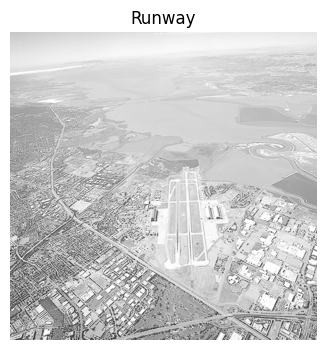

In [2]:
runway = cv2.imread('images/runway.png', 0)
highlights_and_shadows = cv2.imread('images/highlights_and_shadows.jpg')
woman = cv2.imread('images/woman.jpg', 0)
# color_img = cv2.imread('images/gamma.png', 0)

plt.imshow(runway, cmap='gray')
plt.title("Runway")
plt.axis('off')

Question 01

In [3]:
def gamma_correction(image, gamma):
    img = image / 255.0
    result = np.power(img, gamma)
    return (result * 255).astype(np.uint8)

def contrast_stretch(image, r1=0.2, r2=0.8):
    img = image / 255.0
    s = np.zeros_like(img)

    s[img < r1] = 0
    s[(img >= r1) & (img <= r2)] = (img[(img >= r1) & (img <= r2)] - r1) / (r2 - r1)
    s[img > r2] = 1

    return (s * 255).astype(np.uint8)

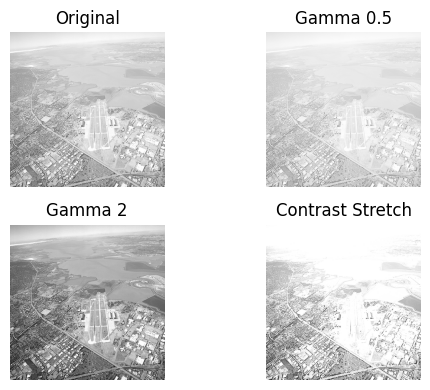

In [4]:
g05 = gamma_correction(runway, 0.5)
g2 = gamma_correction(runway, 2)
cs = contrast_stretch(runway)

titles = ["Original", "Gamma 0.5", "Gamma 2", "Contrast Stretch"]
images = [runway, g05, g2, cs]

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()

Question 2

(np.float64(-0.5), np.float64(719.5), np.float64(479.5), np.float64(-0.5))

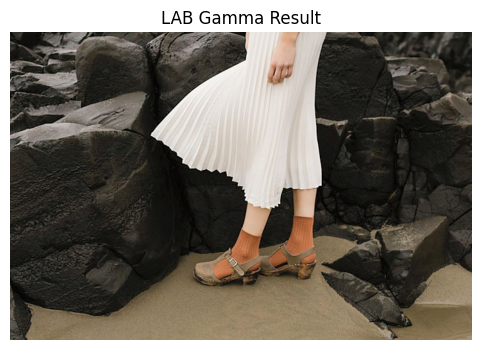

In [5]:
lab = cv2.cvtColor(highlights_and_shadows, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

l_gamma = gamma_correction(l, 0.8)
lab_new = cv2.merge([l_gamma, a, b])
result = cv2.cvtColor(lab_new, cv2.COLOR_LAB2BGR)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("LAB Gamma Result")
plt.axis('off')

Text(0.5, 1.0, 'Histogram Comparison')

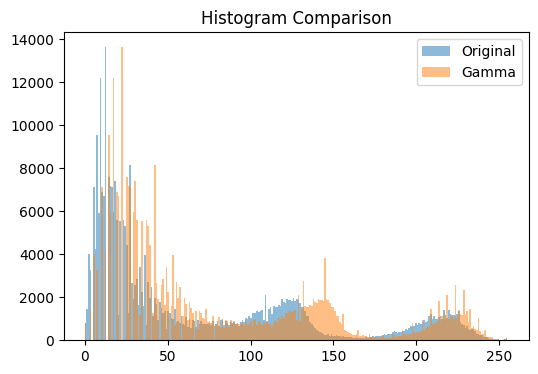

In [6]:
plt.hist(l.flatten(), bins=256, alpha=0.5, label='Original')
plt.hist(l_gamma.flatten(), bins=256, alpha=0.5, label='Gamma')
plt.legend()
plt.title("Histogram Comparison")

Question 3

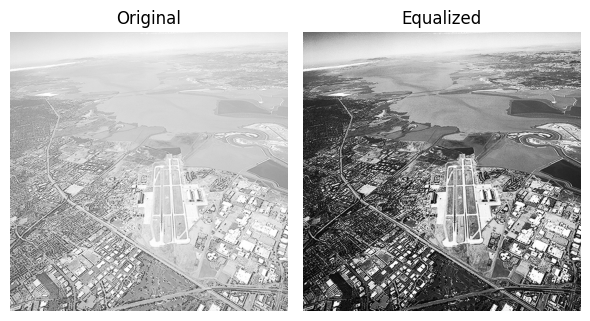

In [12]:
def hist_eq(image):
    hist, bins = np.histogram(image.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf = 255 * cdf / cdf[-1]
    result = np.interp(image.flatten(), bins[:-1], cdf)
    return result.reshape(image.shape).astype(np.uint8)

eq = hist_eq(runway)

plt.subplot(1,2,1)
plt.imshow(runway, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(eq, cmap='gray')
plt.title("Equalized")
plt.axis('off')
plt.tight_layout()

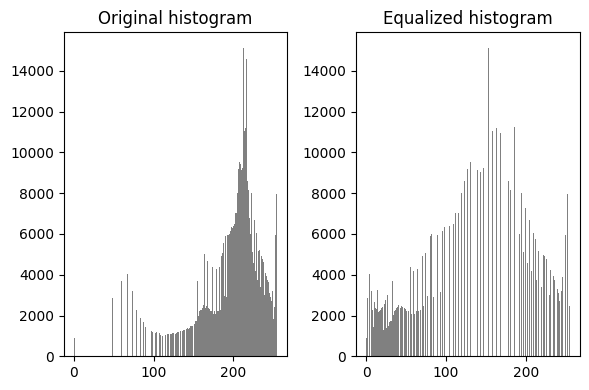

In [13]:
plt.subplot(1,2,1)
plt.hist(runway.flatten(), bins=256, color='gray')
plt.title("Original histogram")

plt.subplot(1,2,2)
plt.hist(eq.flatten(), bins=256, color='gray')
plt.title("Equalized histogram")
plt.tight_layout()

Question 4

Otsu Threshold: 101.0


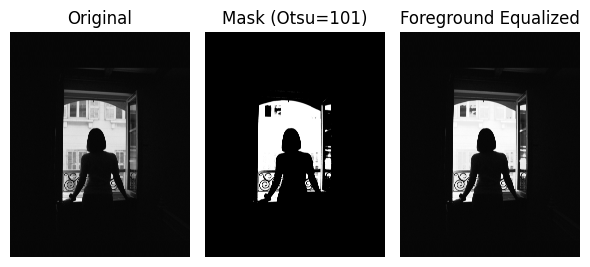

In [ ]:
ret, thresh = cv2.threshold(woman, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Otsu Threshold:", ret)

mask = thresh == 0
eq_woman = hist_eq(woman)

result = woman.copy()
result[mask] = eq_woman[mask]

plt.subplot(1,3,1)
plt.imshow(woman, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title(f"Mask (Otsu={ret:.0f})")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(result, cmap='gray')
plt.title("Foreground Equalized")
plt.axis('off')

plt.tight_layout()

Question 5

In [9]:
def gaussian_kernel(size, sigma):
    ax = np.linspace(-(size//2), size//2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    kernel /= np.sum(kernel)
    return kernel

kernel = gaussian_kernel(5, 2)
print(kernel)

[[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]


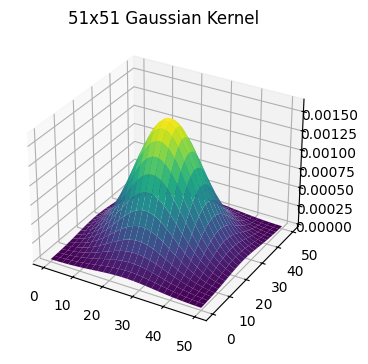

In [22]:
gauss_kernel_51 = gaussian_kernel(51, 10)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x, y = np.meshgrid(np.arange(51), np.arange(51))
ax.plot_surface(x, y, gauss_kernel_51, cmap='viridis')
plt.title("51x51 Gaussian Kernel")
plt.show()

Max abs diff: 1


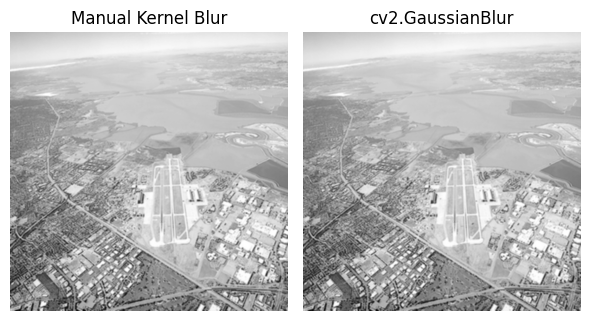

In [ ]:
blur_manual = cv2.filter2D(runway, -1, kernel)
blur_cv = cv2.GaussianBlur(runway, (5,5), 2)

plt.subplot(1, 2, 1)
plt.imshow(blur_manual, cmap='gray')
plt.title("Manual Kernel Blur")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blur_cv, cmap='gray')
plt.title("cv2.GaussianBlur")
plt.axis('off')

plt.tight_layout()

Question 6

(a)
G(x,y) = (1/(2πσ²)) exp(−(x²+y²)/(2σ²))
∂G/∂x = G · ∂/∂x[−(x²+y²)/(2σ²)] = G · (−x/σ²) = −(x/σ²)·G(x,y)
Same logic for y → ∂G/∂y = −(y/σ²)·G(x,y) ✓


Text(0.5, 1.0, 'Gradient X')

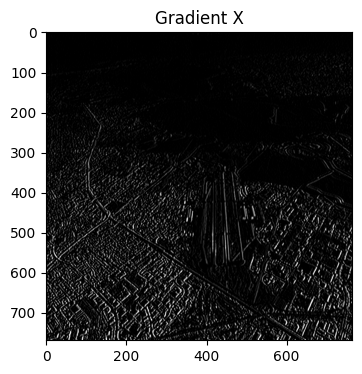

In [25]:
def derivative_gaussian(size=5, sigma=2):
    ax = np.linspace(-(size//2), size//2, size)
    xx, yy = np.meshgrid(ax, ax)

    G = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    Gx = -(xx/sigma**2)*G
    Gy = -(yy/sigma**2)*G

    return Gx, Gy

Gx, Gy = derivative_gaussian()

grad_x = cv2.filter2D(runway, -1, Gx)
grad_y = cv2.filter2D(runway, -1, Gy)

plt.imshow(grad_x, cmap='gray')
plt.title("Gradient X")